In [54]:
from prophet import Prophet
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR if NB_DIR.name != "notebooks" else NB_DIR.parent

data_file = PROJECT_ROOT / "data" / "processed" / "data_prepare_Alzheimer.csv" 

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Archivo:", data_file)


PROJECT_ROOT: /home/jarcos/proyectos/EpiForecast-MX
Archivo: /home/jarcos/proyectos/EpiForecast-MX/data/processed/data_prepare_Alzheimer.csv


In [36]:
df =  pd.read_csv(data_file)
df['Fecha'] = pd.to_datetime(df['Fecha'])
serie = df.groupby("Fecha")[["incrementos_hombres", "incrementos_mujeres"]].sum()
serie

,incrementos_hombres,incrementos_mujeres
Fecha,,
2014-01-01,2,2
2014-01-06,11,14
2014-01-13,15,18
2014-01-20,11,20
2014-01-27,14,22
...,...,...
2025-12-08,16,16
2025-12-15,9,11
2025-12-22,9,12


In [46]:
columna = 'incrementos_hombres'
periodos = 60
df_prophet = serie.reset_index()[["Fecha", columna]]
df_prophet.columns = ["ds", "y"]



16:55:21 - cmdstanpy - INFO - Chain [1] start processing
16:55:21 - cmdstanpy - INFO - Chain [1] done processing


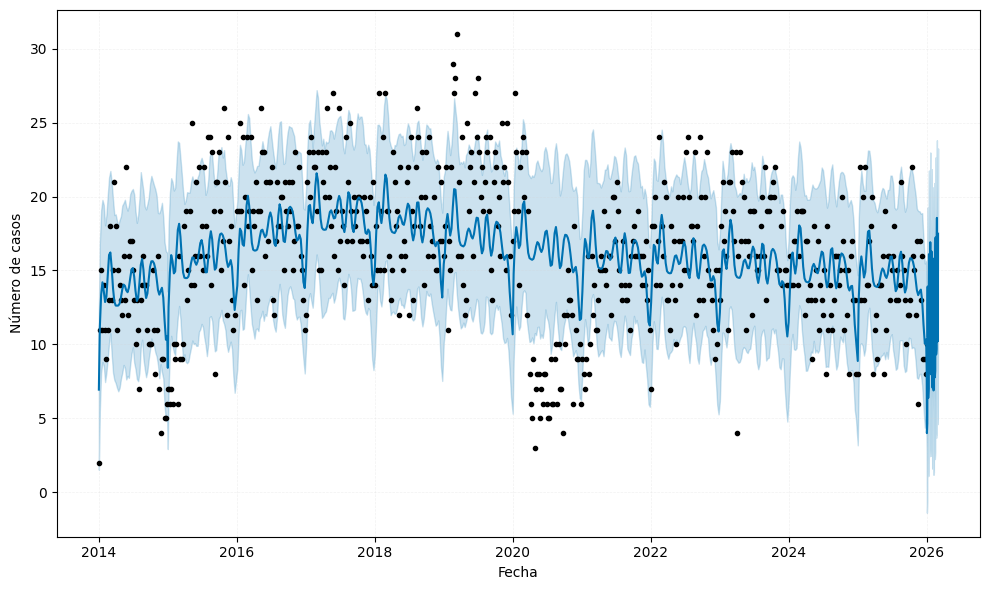

In [59]:
model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=periodos)
forecast = model.predict(future)

fig = model.plot(forecast)

plt.xlabel("Fecha")
plt.ylabel("Número de casos")
plt.grid(True, color="lightgray", alpha=0.3, linestyle="--", linewidth=0.5)
plt.show()

In [ ]:

df_cv = cross_validation(
    model=model,
    initial='1095 days',
    period='180 days',
    horizon='365 days'
)


  0%|          | 0/17 [00:00<?, ?it/s]16:49:26 - cmdstanpy - INFO - Chain [1] start processing
16:49:26 - cmdstanpy - INFO - Chain [1] done processing
  6%|▌         | 1/17 [00:00<00:02,  7.95it/s]16:49:26 - cmdstanpy - INFO - Chain [1] start processing
16:49:26 - cmdstanpy - INFO - Chain [1] done processing
 12%|█▏        | 2/17 [00:00<00:01,  8.89it/s]16:49:26 - cmdstanpy - INFO - Chain [1] start processing
16:49:26 - cmdstanpy - INFO - Chain [1] done processing
16:49:26 - cmdstanpy - INFO - Chain [1] start processing
16:49:26 - cmdstanpy - INFO - Chain [1] done processing
 24%|██▎       | 4/17 [00:00<00:01,  9.85it/s]16:49:26 - cmdstanpy - INFO - Chain [1] start processing
16:49:26 - cmdstanpy - INFO - Chain [1] done processing
 29%|██▉       | 5/17 [00:00<00:01,  9.88it/s]16:49:27 - cmdstanpy - INFO - Chain [1] start processing
16:49:27 - cmdstanpy - INFO - Chain [1] done processing
 35%|███▌      | 6/17 [00:00<00:01,  9.88it/s]16:49:27 - cmdstanpy - INFO - Chain [1] start processi

In [56]:
df_p = performance_metrics(df_cv, rolling_window=0.1) 
df_p[['horizon','mae','rmse','mape','coverage']].head()


,horizon,mae,rmse,mape,coverage
0,36 days,3.647048,4.660808,0.260499,0.761364
1,37 days,3.788685,4.836840,0.256852,0.746212
2,38 days,3.693604,4.676182,0.251645,0.750000
3,39 days,3.752109,4.714035,0.254477,0.750000
4,40 days,3.814032,4.761263,0.258083,0.727273


/home/jarcos/miniconda3/envs/integrador/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/jarcos/miniconda3/envs/integrador/lib/python3.12/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


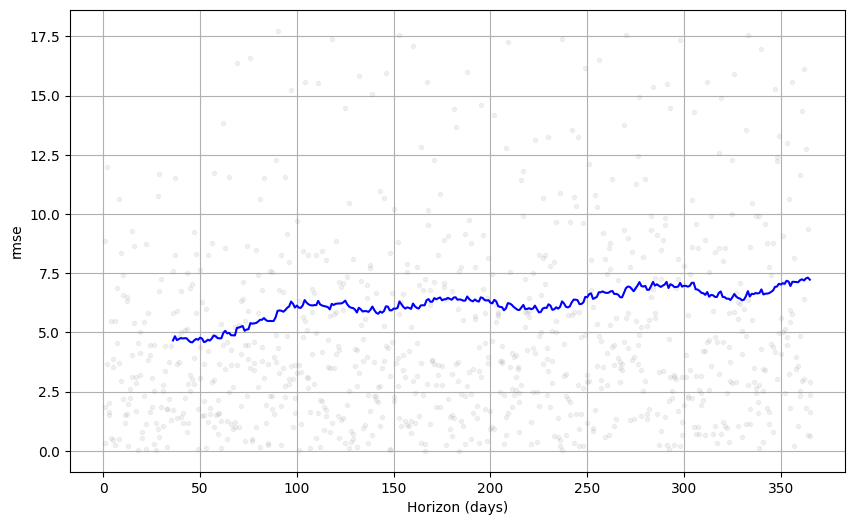

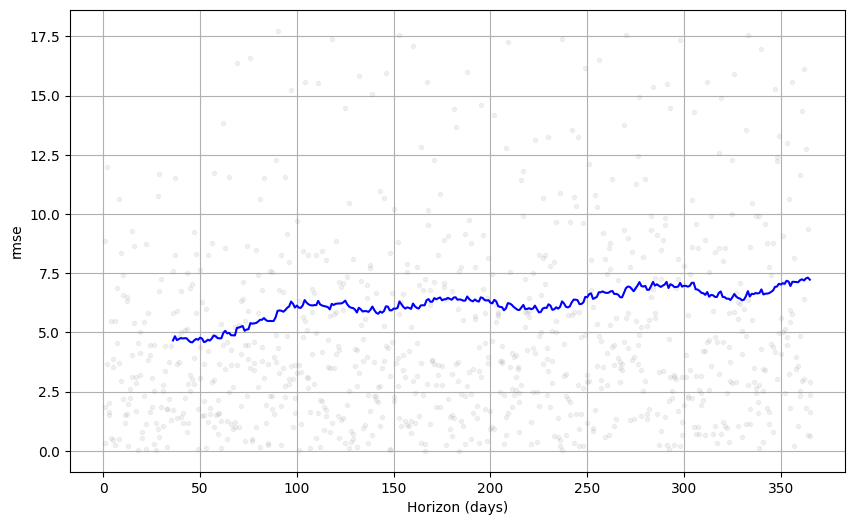

In [55]:
plot_cross_validation_metric(df_cv, metric='rmse')
